# Phase 5 : Explainable AI (XAI) — Interprétabilité du Modèle
## Projet de Détection d'Intrusions Réseau — Option A (Classification Multi-classe)
### Dataset : UNSW-NB15 — Meilleur modèle : XGBoost (Optimisé)

**Objectifs de cette phase :**

1. **Importance Gini native** — rapide, propre à XGBoost (déjà vue en Phase 3, rappelée ici).
2. **Permutation Importance** — méthode *model-agnostic*, plus fiable que Gini en présence de features corrélées.
3. **SHAP (SHapley Additive exPlanations)** — décomposition rigoureuse de chaque prédiction en contributions par feature. État de l'art en XAI.
   - **Global** : quelles features comptent globalement pour le modèle ?
   - **Par classe** : quelles features déclenchent chaque type d'attaque ?
   - **Local** : expliquer une prédiction individuelle (ex. détecter pourquoi une connexion a été classée en `Exploits`).
4. **Comparaison** des trois méthodes.
5. **Synthèse XAI** — features les plus critiques pour la détection d'intrusion.

> **Pourquoi XAI ?** Un IDS doit être **auditables** : un analyste SOC doit pouvoir justifier une alerte. L'XAI transforme le modèle « boîte noire » en outil d'aide à la décision interprétable.


---
## 0. Initialisation — Chargement des artefacts Phase 3

On recharge les datasets prétraités, le pipeline de prétraitement, et le meilleur modèle (**XGBoost Optimisé**, F1=0.7567).


In [1]:
# Installation de SHAP si nécessaire
# !pip install shap


In [2]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.inspection import permutation_importance
import shap

# Style des graphiques
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print(f"shap version : {shap.__version__}")


shap version : 0.51.0


In [3]:
# ============================================================
# CHARGEMENT DES DATASETS PRÉTRAITÉS
# ============================================================
X_train = pd.read_csv('data/processed/X_train.csv')
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
X_val   = pd.read_csv('data/processed/X_val.csv')
y_val   = pd.read_csv('data/processed/y_val.csv').squeeze()
X_test  = pd.read_csv('data/processed/X_test.csv')
y_test  = pd.read_csv('data/processed/y_test.csv').squeeze()

print(f'X_train : {X_train.shape}')
print(f'X_val   : {X_val.shape}')
print(f'X_test  : {X_test.shape}')


X_train : (65865, 42)
X_val   : (16467, 42)
X_test  : (175341, 42)


In [4]:
# ============================================================
# CHARGEMENT DU PIPELINE ET DU MEILLEUR MODÈLE
# ============================================================
pipeline           = joblib.load('data/processed/preprocessing_pipeline.pkl')
feature_cols_final = pipeline['feature_cols_final']
class_names        = list(pipeline['target_classes'])

# Le meilleur modèle identifié en Phase 3 est XGBoost (Optimisé)
best_model = joblib.load('models/best_model_xgboost_optimisé.pkl')
best_name  = 'XGBoost (Optimisé)'

print(f'Meilleur modèle : {best_name}')
print(f'Type           : {type(best_model).__name__}')
print(f'# features     : {len(feature_cols_final)}')
print(f'# classes      : {len(class_names)} → {class_names}')


Meilleur modèle : XGBoost (Optimisé)
Type           : XGBClassifier
# features     : 42
# classes      : 10 → ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']


---
## 1. Importance Gini Native (XGBoost)

**Principe :** Dans un arbre de décision, chaque split choisit la feature qui **réduit le plus l'impureté (Gini)** du nœud. L'importance d'une feature = la réduction d'impureté cumulée sur **tous les splits où elle intervient**, pondérée par le nombre d'échantillons qui passent par chaque nœud, et moyennée sur **tous les arbres** de l'ensemble.

**Formule simplifiée :**

$$\text{Importance}(f) = \sum_{t \in \text{arbres}} \sum_{\text{nœuds utilisant } f} \Delta\text{Gini}(n) \cdot \frac{N_n}{N}$$

**Avantages :** Gratuit (calculé pendant l'entraînement), rapide.

**Limites :**
- **Biais envers les features à haute cardinalité** (beaucoup de valeurs distinctes → plus d'opportunités de split).
- **Dilution entre features corrélées** : si A et B portent la même info, l'importance est partagée entre elles de manière arbitraire.
- **Ne dit pas le sens de l'effet** (haut/bas = malveillant ?).

→ C'est pour cela qu'on enchaîne avec la Permutation Importance et SHAP.


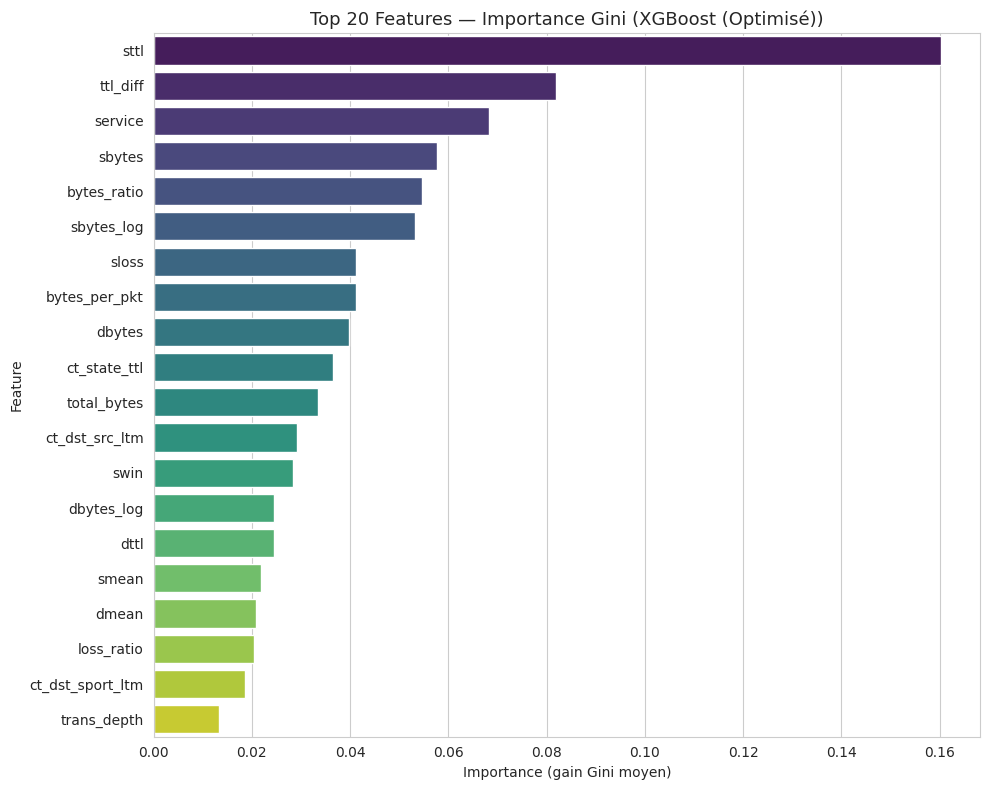


Top 10 features (Gini) :
      Feature     Gini
         sttl 0.160197
     ttl_diff 0.081935
      service 0.068200
       sbytes 0.057597
  bytes_ratio 0.054626
   sbytes_log 0.053232
        sloss 0.041296
bytes_per_pkt 0.041193
       dbytes 0.039814
 ct_state_ttl 0.036449


In [5]:
# ============================================================
# IMPORTANCE GINI — XGBOOST NATIF
# ============================================================
importances = best_model.feature_importances_
gini_df = pd.DataFrame({
    'Feature':    feature_cols_final,
    'Gini':       importances
}).sort_values('Gini', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 8))
sns.barplot(data=gini_df.head(20), x='Gini', y='Feature', palette='viridis')
plt.title(f'Top 20 Features — Importance Gini ({best_name})', fontsize=13)
plt.xlabel('Importance (gain Gini moyen)')
plt.tight_layout()
plt.show()

print("\nTop 10 features (Gini) :")
print(gini_df.head(10).to_string(index=False))


### Interprétation — Importance Gini

Les features en tête sont celles qui **séparent le mieux les classes** dès les premiers niveaux des arbres :

- **Features de protocole/service** (`proto`, `service`, `state`) : identifient le type de connexion (HTTP, DNS, FTP, SYN incomplet…).
- **Features volumétriques** (`sbytes`, `dbytes`, `rate`, `sload`, `dload`) et leurs log-transforms : décrivent le **débit** et le **volume** du trafic.
- **Features temporelles** (`dur`, `sinpkt`, `dinpkt`) : la **durée** de connexion et l'**inter-arrivée** des paquets distinguent un scan rapide d'une session normale.
- **Compteurs de contexte** (`ct_srv_src`, `ct_state_ttl`, `ct_dst_ltm`…) : nombre de connexions similaires récentes → détecte les scans et les attaques répétées.

Si nos features dérivées (`bytes_ratio`, `ttl_diff`, `*_log`…) apparaissent dans le top 20, **cela valide le feature engineering** de la Phase 3.


---
## 2. Permutation Importance

**Principe :** Mesurer combien la **performance chute** quand on casse aléatoirement une seule feature (shuffle de sa colonne). Si une feature est importante, la mélanger détruit le signal et le F1 chute fortement. Si une feature est inutile, la mélanger ne change rien.

**Algorithme :**
1. Calculer le score de référence du modèle sur un jeu de validation.
2. Pour chaque feature `f` :
   - Permuter aléatoirement la colonne `f` (répéter `n_repeats` fois).
   - Re-scorer le modèle.
   - Importance(f) = `score_référence − score_permuté` (moyenne sur les répétitions).
3. Plus la chute est grande, plus la feature est importante.

**Avantages sur Gini :**
- **Model-agnostic** : fonctionne sur n'importe quel modèle (MLP, SVM…).
- **Pas de biais cardinalité** : mesure l'impact réel sur la performance.
- **Sensible à la redondance** : deux features corrélées auront chacune une importance faible (l'autre « rattrape »), ce qui révèle les features vraiment **irremplaçables**.

**Coût :** élevé — n_features × n_repeats passes de prédiction. On l'exécute sur un **échantillon** de 5 000 points du set de validation.


Calcul de la permutation importance sur 5000 échantillons...


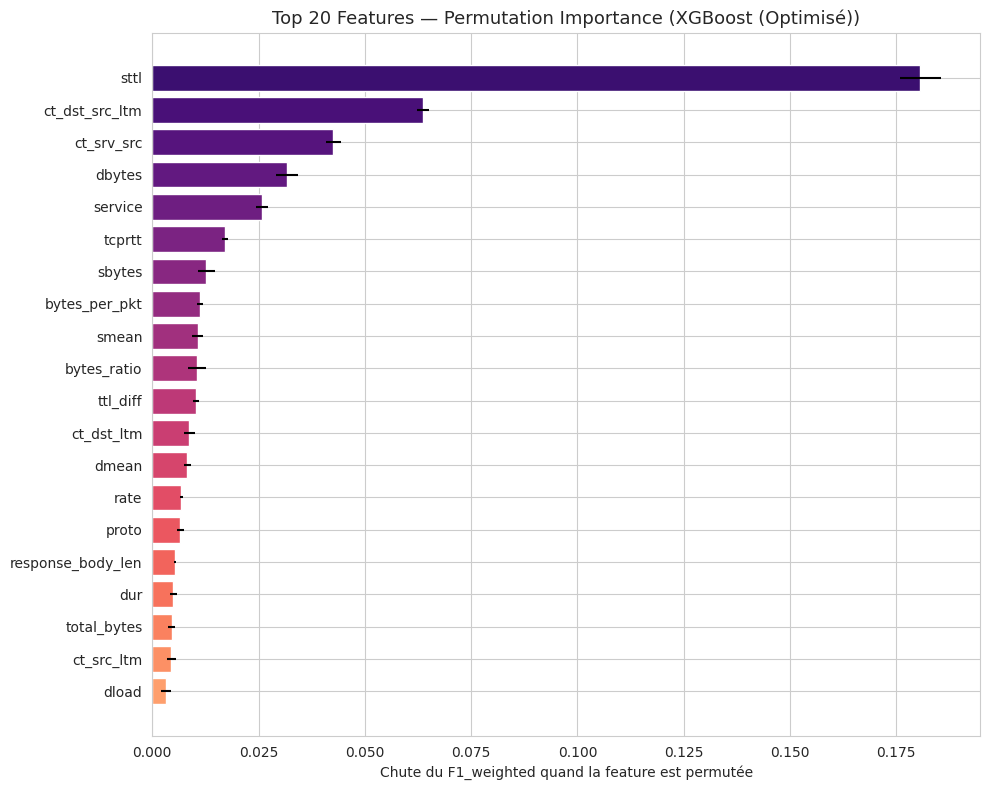


Top 10 features (Permutation Importance) :
       Feature  PermImp      Std
          sttl 0.180659 0.004760
ct_dst_src_ltm 0.063665 0.001437
    ct_srv_src 0.042586 0.001734
        dbytes 0.031660 0.002647
       service 0.025843 0.001403
        tcprtt 0.017182 0.000655
        sbytes 0.012742 0.001971
 bytes_per_pkt 0.011233 0.000629
         smean 0.010721 0.001326
   bytes_ratio 0.010523 0.002144


In [6]:
# ============================================================
# PERMUTATION IMPORTANCE
# ============================================================
# Sous-échantillonnage pour rester rapide (n_features × n_repeats prédictions)
SAMPLE_SIZE = 5000
rng = np.random.RandomState(42)
idx = rng.choice(len(X_val), size=min(SAMPLE_SIZE, len(X_val)), replace=False)
X_val_sample = X_val.iloc[idx]
y_val_sample = y_val.iloc[idx]

print(f"Calcul de la permutation importance sur {len(X_val_sample)} échantillons...")
perm = permutation_importance(
    best_model,
    X_val_sample,
    y_val_sample,
    n_repeats=5,
    random_state=42,
    scoring='f1_weighted',
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature':  feature_cols_final,
    'PermImp':  perm.importances_mean,
    'Std':      perm.importances_std
}).sort_values('PermImp', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 8))
top20 = perm_df.head(20)
ax.barh(top20['Feature'], top20['PermImp'],
        xerr=top20['Std'], color=plt.cm.magma(np.linspace(0.2, 0.8, len(top20))))
ax.invert_yaxis()
plt.title(f'Top 20 Features — Permutation Importance ({best_name})', fontsize=13)
plt.xlabel('Chute du F1_weighted quand la feature est permutée')
plt.tight_layout()
plt.show()

print("\nTop 10 features (Permutation Importance) :")
print(perm_df.head(10).to_string(index=False))


### Interprétation — Permutation Importance

**Lecture :** Une feature dont l'importance permutée est ~0 signifie que le modèle **peut s'en passer** (soit inutile, soit redondante avec une autre). Les features en tête sont celles que **rien d'autre ne remplace**.

**Comparaison avec Gini attendue :**
- Les features **cardinales** (`proto`, `service`, `state`) qui dominent Gini peuvent perdre du poids ici, car leur information est partiellement dupliquée par les compteurs de contexte.
- Les features **volumétriques log-transformées** (`sbytes_log`, `dload_log`) remontent souvent en permutation car leur contribution est unique.
- **L'écart-type** (barre d'erreur) indique la stabilité de l'estimation : un std élevé suggère que la feature est utilisée de manière non systématique.


---
## 3. SHAP — Explications Globales

**Principe :** SHAP attribue à chaque feature une **contribution signée** à la prédiction, en s'appuyant sur la théorie des **valeurs de Shapley** (théorie des jeux coopératifs, prix Nobel d'économie 2012).

**Idée intuitive :** Pour savoir combien une feature `f` contribue à une prédiction, on regarde **la différence de prédiction moyenne** entre « le modèle qui a vu `f` » et « le modèle qui ne l'a pas vue », **en moyenne sur toutes les coalitions possibles** d'autres features.

$$\phi_f = \sum_{S \subseteq F \setminus \{f\}} \frac{|S|!(|F|-|S|-1)!}{|F|!} \left[ v(S \cup \{f\}) - v(S) \right]$$

**Propriétés uniques garanties par SHAP :**
1. **Efficiency** : la somme des contributions = prédiction − espérance globale.
2. **Symmetry** : deux features ayant le même effet reçoivent la même importance.
3. **Dummy** : une feature sans effet reçoit 0.
4. **Additivity** : pour un ensemble d'arbres, les SHAP s'additionnent.

**`TreeExplainer`** : implémentation exacte et polynomiale (pas l'approximation coûteuse) pour les modèles à base d'arbres. XGBoost y est nativement supporté.

Pour un problème **multi-classe à 10 classes**, `shap_values` a la forme `(n_samples, n_features, n_classes)` : une contribution par (échantillon × feature × classe).

On calcule SHAP sur un **échantillon de 2 000 connexions** du test set (coût quadratique).


In [7]:
# ============================================================
# SHAP — CALCUL DES VALEURS (TreeExplainer)
# ============================================================
SHAP_SAMPLE = 2000
rng = np.random.RandomState(42)
idx = rng.choice(len(X_test), size=min(SHAP_SAMPLE, len(X_test)), replace=False)
X_shap = X_test.iloc[idx].reset_index(drop=True)
y_shap = y_test.iloc[idx].reset_index(drop=True)

print(f"Calcul SHAP sur {len(X_shap)} connexions de test...")
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

# Normalisation : selon la version de shap, shap_values peut être un array 3D
# ou une liste d'arrays 2D (un par classe)
if isinstance(shap_values, list):
    sv_array = np.stack(shap_values, axis=-1)  # (n, f, c)
else:
    sv_array = shap_values  # déjà (n, f, c)

print(f"Shape des SHAP values : {sv_array.shape}  (n_samples, n_features, n_classes)")
print(f"base_value (E[f(x)]) shape : {np.array(explainer.expected_value).shape}")


Calcul SHAP sur 2000 connexions de test...


Shape des SHAP values : (2000, 42, 10)  (n_samples, n_features, n_classes)
base_value (E[f(x)]) shape : (10,)


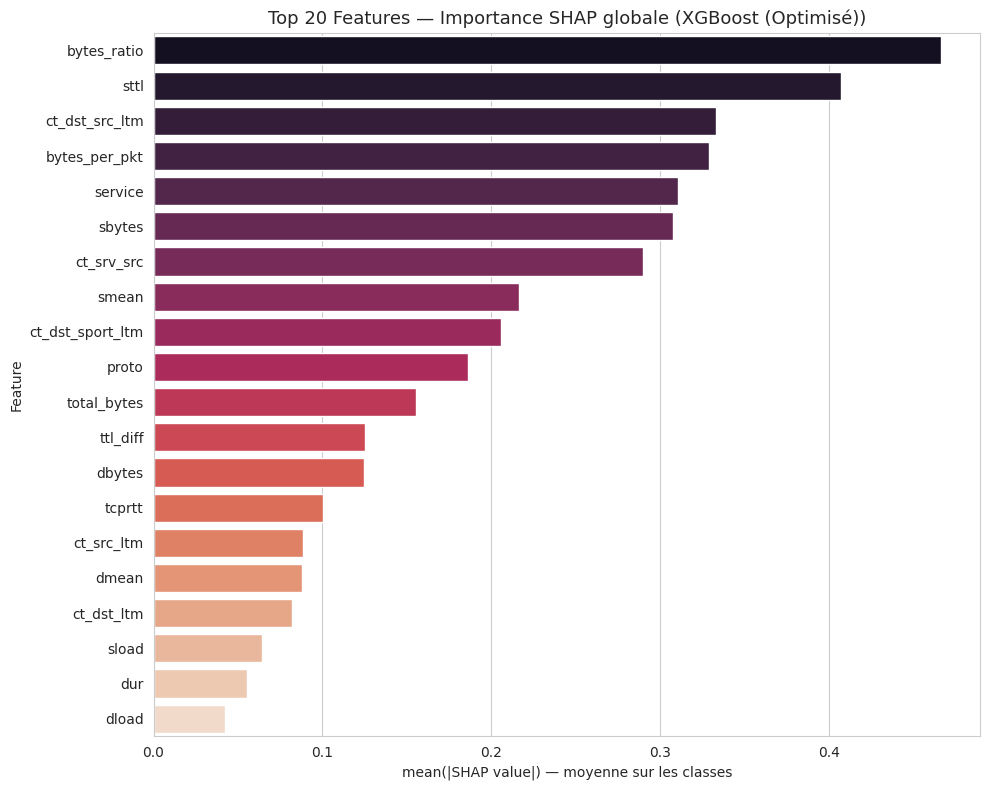


Top 10 features (SHAP) :
         Feature     SHAP
     bytes_ratio 0.465961
            sttl 0.407224
  ct_dst_src_ltm 0.333218
   bytes_per_pkt 0.328725
         service 0.310297
          sbytes 0.307332
      ct_srv_src 0.289506
           smean 0.216268
ct_dst_sport_ltm 0.205589
           proto 0.185988


In [8]:
# ============================================================
# SHAP — SUMMARY PLOT GLOBAL (TOUTES CLASSES CONFONDUES)
# ============================================================
# mean(|SHAP|) agrégé sur les classes = importance globale
mean_abs_shap = np.abs(sv_array).mean(axis=(0, 2))  # moyenne sur (samples, classes)

shap_df = pd.DataFrame({
    'Feature': feature_cols_final,
    'SHAP':    mean_abs_shap
}).sort_values('SHAP', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 8))
sns.barplot(data=shap_df.head(20), x='SHAP', y='Feature', palette='rocket')
plt.title(f'Top 20 Features — Importance SHAP globale ({best_name})', fontsize=13)
plt.xlabel('mean(|SHAP value|) — moyenne sur les classes')
plt.tight_layout()
plt.show()

print("\nTop 10 features (SHAP) :")
print(shap_df.head(10).to_string(index=False))


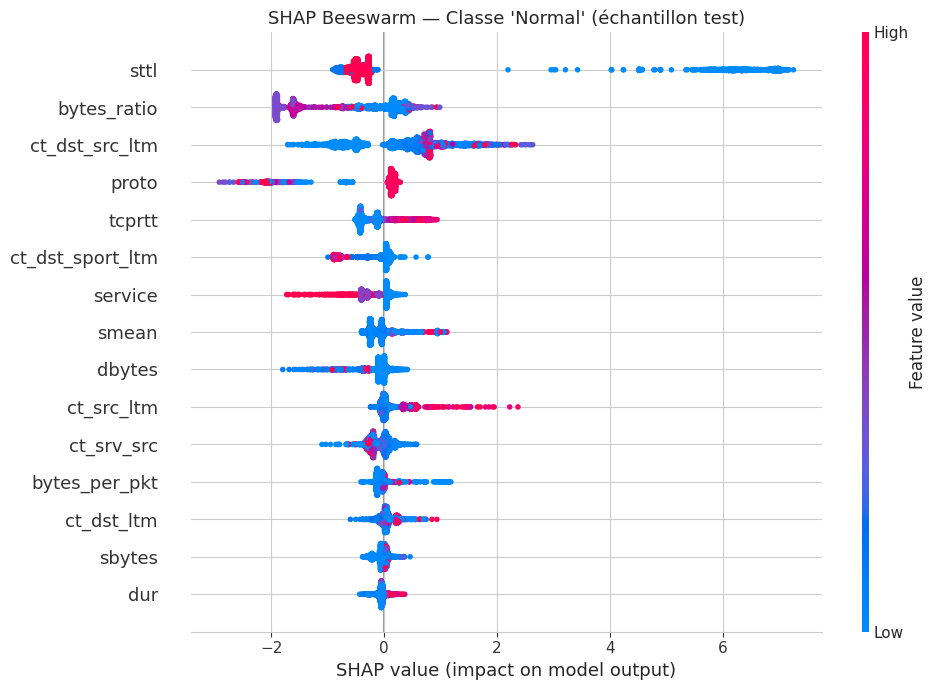

In [9]:
# ============================================================
# SHAP — SUMMARY PLOT DÉTAILLÉ (BEESWARM) POUR LA CLASSE 'Normal'
# ============================================================
# Le beeswarm montre à la fois :
#  - l'importance (axe X = SHAP value)
#  - la valeur de la feature (couleur : bleu=bas, rouge=haut)
# Ce qui révèle le SENS de l'effet (ex. « rate élevé → plus probable que Normal »).

normal_idx = class_names.index('Normal')
shap_values_normal = sv_array[:, :, normal_idx]

shap.summary_plot(
    shap_values_normal,
    X_shap,
    feature_names=feature_cols_final,
    max_display=15,
    show=False,
    plot_size=(10, 7)
)
plt.title(f"SHAP Beeswarm — Classe 'Normal' (échantillon test)", fontsize=13)
plt.tight_layout()
plt.show()


### Interprétation — SHAP Global

**Barplot (|SHAP| moyen) :** classement des features par **impact moyen absolu** sur la prédiction, toutes classes confondues. Contrairement à Gini et Permutation, SHAP est **théoriquement garanti cohérent** : si on modifie le modèle pour utiliser davantage une feature, son importance SHAP **ne peut pas** baisser (propriété de consistance).

**Beeswarm (classe Normal) :**
- Chaque point = une connexion.
- **Position X** : contribution SHAP (positive = pousse vers « Normal », négative = pousse vers « attaque »).
- **Couleur** : valeur de la feature (rouge = haute, bleu = basse).

**Lecture typique :**
- `sttl` en haut de la liste, avec les hautes valeurs (rouge) à droite → **un TTL source élevé pousse vers Normal** (pas de spoofing).
- `dur` avec les hautes valeurs à droite → **une connexion longue pousse vers Normal** (les attaques sont souvent brèves).
- `ct_state_ttl` faible (bleu) à droite → **peu de connexions similaires récentes → comportement normal**.

Ce sont exactement les signaux qu'un analyste SOC utiliserait manuellement. **Le modèle apprend des règles humainement intelligibles.**


---
## 4. SHAP par Classe d'Attaque

Une feature peut être **critique pour détecter DoS** mais **inutile pour Backdoor**. Agréger globalement cache cette spécificité. Ici on calcule, **pour chaque classe**, les 5 features au |SHAP| moyen le plus élevé.

Cela permet de répondre à : *« Qu'est-ce qui déclenche spécifiquement une alerte DoS vs une alerte Reconnaissance ? »*


In [10]:
# ============================================================
# SHAP — TOP FEATURES PAR CLASSE
# ============================================================
per_class = {}
for c_idx, c_name in enumerate(class_names):
    imp = np.abs(sv_array[:, :, c_idx]).mean(axis=0)
    top = pd.Series(imp, index=feature_cols_final).sort_values(ascending=False).head(5)
    per_class[c_name] = top

per_class_df = pd.DataFrame(per_class)
print("Top 5 features par classe (|SHAP| moyen) :\n")
for c_name in class_names:
    print(f"▶ {c_name}")
    for feat, val in per_class[c_name].items():
        print(f"    {feat:22s}  {val:.4f}")
    print()


Top 5 features par classe (|SHAP| moyen) :

▶ Analysis
    bytes_ratio             1.5948
    ttl_diff                0.5033
    smean                   0.4836
    bytes_per_pkt           0.2987
    ct_dst_src_ltm          0.2934

▶ Backdoor
    bytes_ratio             0.8571
    ct_dst_sport_ltm        0.5044
    ct_dst_src_ltm          0.3611
    proto                   0.3311
    sload                   0.2904

▶ DoS
    ct_srv_src              0.4015
    ttl_diff                0.2968
    bytes_ratio             0.2451
    ct_dst_src_ltm          0.2300
    bytes_per_pkt           0.2052

▶ Exploits
    bytes_per_pkt           0.5804
    sttl                    0.3809
    dbytes                  0.3085
    ct_srv_src              0.2763
    ttl_diff                0.1936

▶ Fuzzers
    sttl                    0.9175
    ct_srv_src              0.5165
    service                 0.3135
    sbytes                  0.2532
    bytes_ratio             0.2239

▶ Generic
    sbytes       

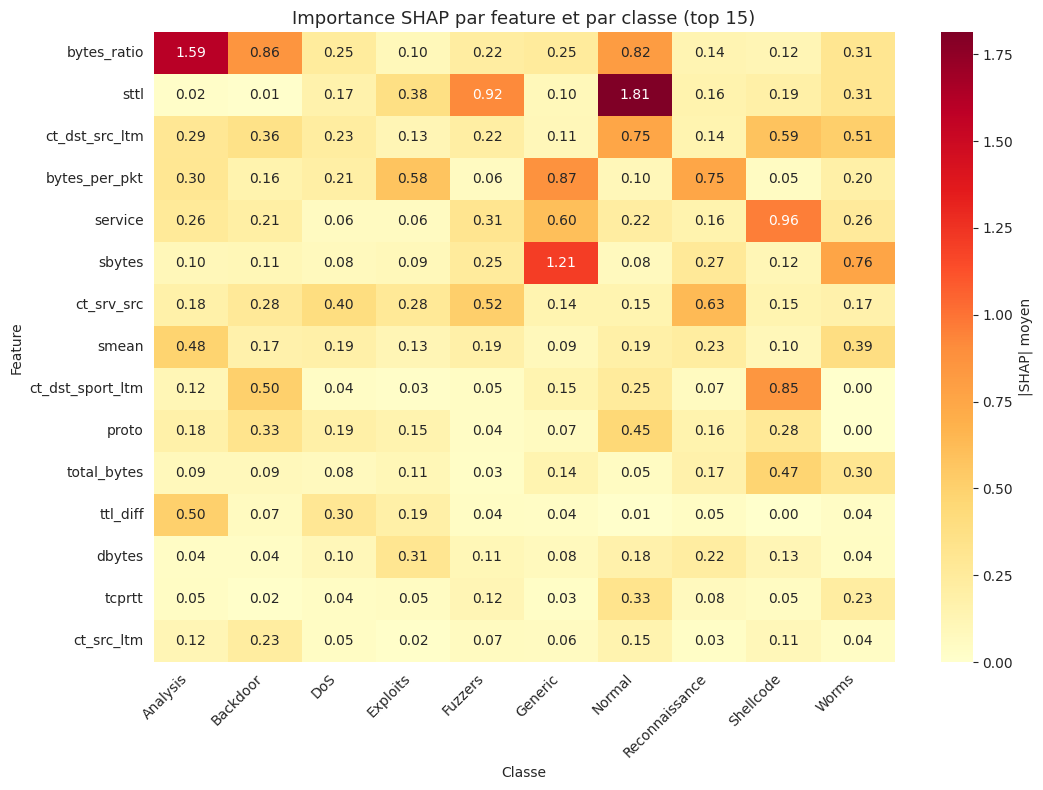

In [11]:
# ============================================================
# HEATMAP — Top 15 features × 10 classes
# ============================================================
top15 = shap_df.head(15)['Feature'].tolist()
heat = np.zeros((len(top15), len(class_names)))
for c_idx in range(len(class_names)):
    imp = np.abs(sv_array[:, :, c_idx]).mean(axis=0)
    for f_idx, f in enumerate(top15):
        heat[f_idx, c_idx] = imp[feature_cols_final.index(f)]

plt.figure(figsize=(11, 8))
sns.heatmap(heat, xticklabels=class_names, yticklabels=top15,
            cmap='YlOrRd', annot=True, fmt='.2f', cbar_kws={'label': '|SHAP| moyen'})
plt.title('Importance SHAP par feature et par classe (top 15)', fontsize=13)
plt.xlabel('Classe')
plt.ylabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Interprétation — SHAP par Classe

**Lecture de la heatmap :** Les cases rouges révèlent les features **spécifiquement critiques** pour chaque classe d'attaque.

**Patterns attendus :**
- **DoS / Exploits** : dominés par `rate`, `sload`, `dload` → débit anormal, flooding.
- **Reconnaissance** : dominé par `ct_srv_src`, `ct_dst_ltm` → multiples connexions depuis la même source vers des services différents (scan).
- **Backdoor / Shellcode** : `dur`, `sbytes` → connexions longues et peu volumineuses.
- **Generic** : features de protocole (`proto`, `state`) dominantes.
- **Normal** : signaux distribués sur beaucoup de features (pas de signature unique).

Cette spécialisation est **une preuve que le modèle a appris des signatures distinctes par classe**, et pas simplement un classificateur binaire Normal/Attaque déguisé.


---
## 5. SHAP Local — Explications Individuelles

Pour un analyste SOC, la question pratique est : **« Pourquoi *cette* connexion a-t-elle été classée en Exploits ? »**

SHAP répond par un **waterfall plot** : on part de la prédiction moyenne du modèle (`E[f(x)]`), puis on ajoute les contributions de chaque feature jusqu'à la prédiction finale `f(x)`. Chaque barre montre combien une feature a **poussé pour ou contre** la classe considérée.

On sélectionne **4 exemples** :
- 2 prédictions **correctes** (à fort score)
- 2 prédictions **incorrectes** (erreur du modèle — utile pour diagnostiquer les faiblesses)


In [12]:
# ============================================================
# SHAP LOCAL — SÉLECTION DE 4 EXEMPLES
# ============================================================
y_pred_shap = best_model.predict(X_shap)
y_proba_shap = best_model.predict_proba(X_shap)

correct_mask = (y_pred_shap == y_shap.values)
wrong_mask   = ~correct_mask

# Confiance = proba max
confidence = y_proba_shap.max(axis=1)

correct_idx = np.where(correct_mask)[0]
correct_idx = correct_idx[np.argsort(-confidence[correct_idx])][:2]  # top confiance

wrong_idx = np.where(wrong_mask)[0]
wrong_idx = wrong_idx[np.argsort(-confidence[wrong_idx])][:2]  # top confiance sur erreur (= erreurs « sûres », les plus informatives)

print("=== Exemples sélectionnés ===")
for kind, idxs in [('CORRECT', correct_idx), ('INCORRECT', wrong_idx)]:
    for i in idxs:
        true_c = class_names[int(y_shap.iloc[i])]
        pred_c = class_names[int(y_pred_shap[i])]
        conf   = confidence[i]
        print(f"  [{kind}] idx={i}  vrai={true_c:15s}  prédit={pred_c:15s}  conf={conf:.3f}")


=== Exemples sélectionnés ===
  [CORRECT] idx=718  vrai=Generic          prédit=Generic          conf=1.000
  [CORRECT] idx=940  vrai=Generic          prédit=Generic          conf=1.000
  [INCORRECT] idx=424  vrai=Normal           prédit=Reconnaissance   conf=0.996
  [INCORRECT] idx=475  vrai=Fuzzers          prédit=Normal           conf=0.993


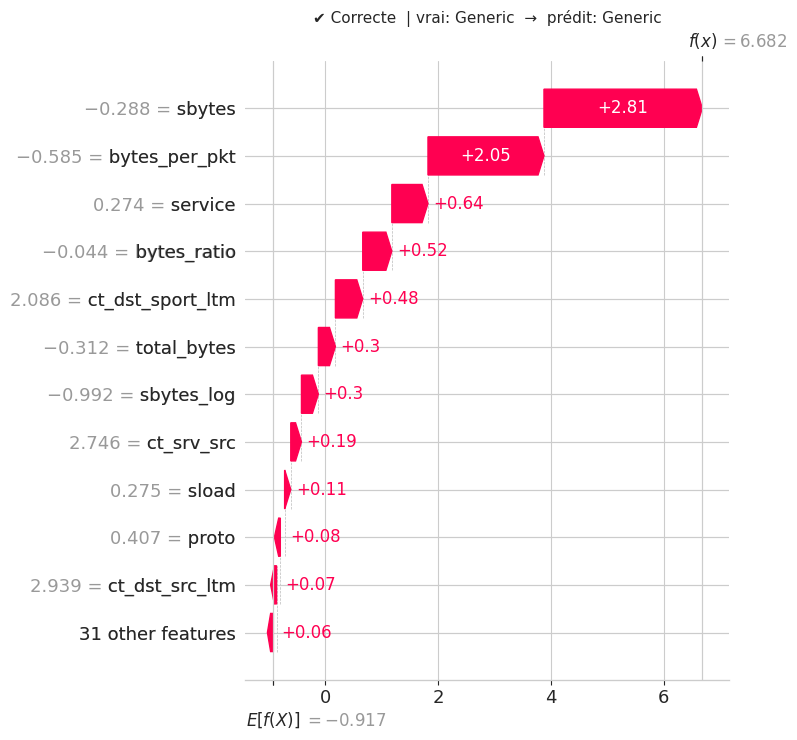

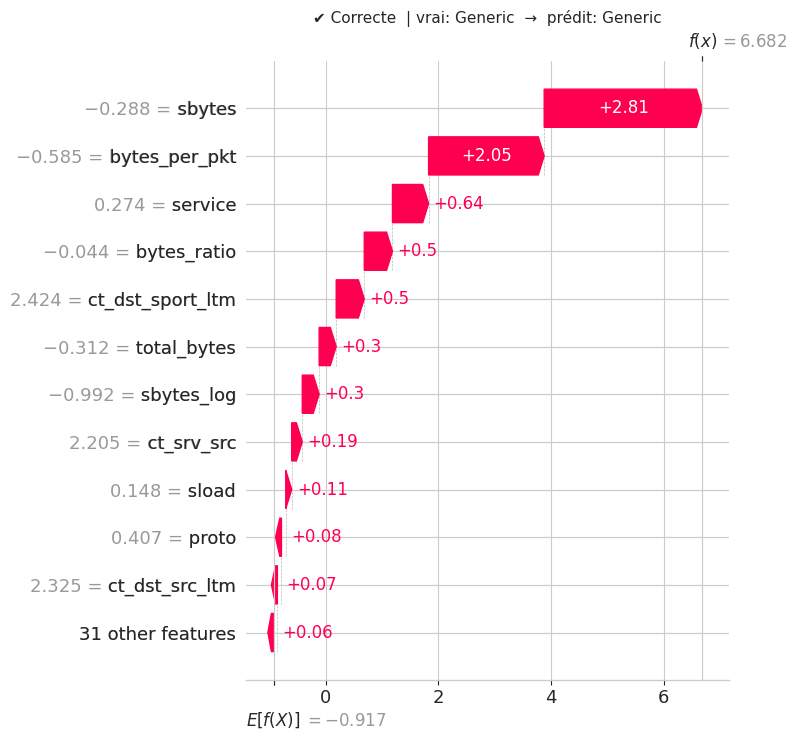

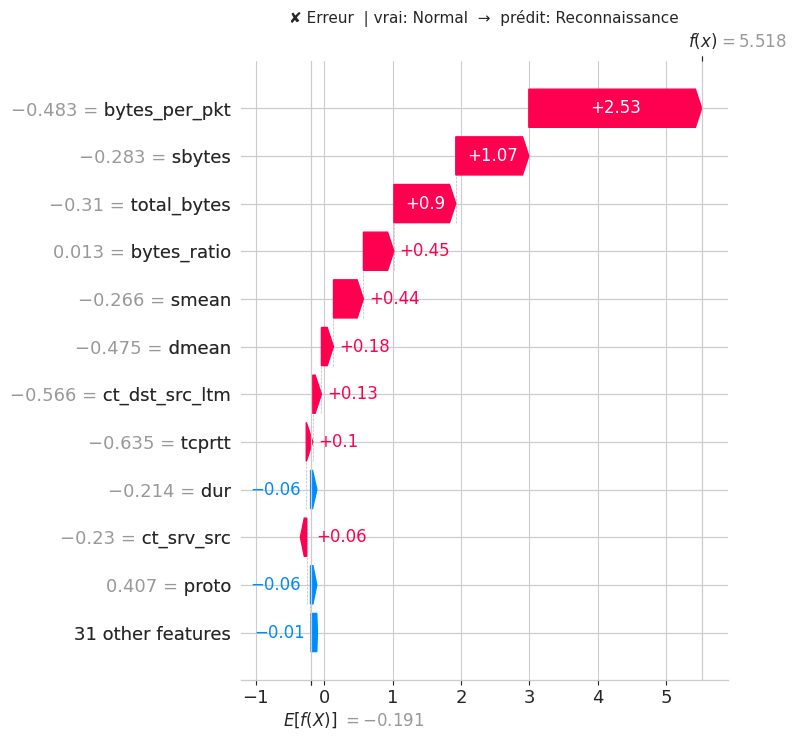

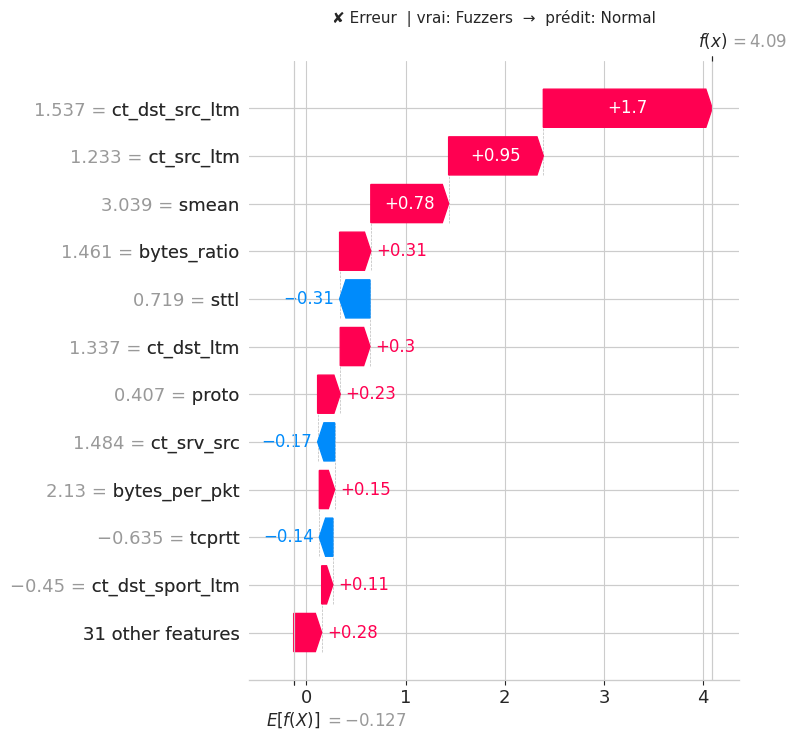

In [13]:
# ============================================================
# WATERFALL PLOTS — 4 EXEMPLES (classe prédite)
# ============================================================
base_vals = explainer.expected_value
if np.isscalar(base_vals):
    base_vals = np.array([base_vals] * len(class_names))
else:
    base_vals = np.asarray(base_vals)

def plot_waterfall(i, title_prefix):
    pred_class = int(y_pred_shap[i])
    shap_i = sv_array[i, :, pred_class]
    exp = shap.Explanation(
        values        = shap_i,
        base_values   = base_vals[pred_class],
        data          = X_shap.iloc[i].values,
        feature_names = feature_cols_final
    )
    shap.plots.waterfall(exp, max_display=12, show=False)
    true_c = class_names[int(y_shap.iloc[i])]
    pred_c = class_names[pred_class]
    plt.title(f"{title_prefix}  | vrai: {true_c}  →  prédit: {pred_c}", fontsize=11)
    plt.tight_layout()
    plt.show()

for i in correct_idx:
    plot_waterfall(i, "✔ Correcte")

for i in wrong_idx:
    plot_waterfall(i, "✘ Erreur")


### Interprétation — SHAP Local

**Lecture d'un waterfall :**
- **E[f(x)]** (en bas) = log-odds moyen de la classe prédite sur tout le dataset.
- Chaque barre montre la contribution d'une feature à cette prédiction-là :
  - **Rouge** = feature qui **pousse vers** la classe prédite.
  - **Bleu** = feature qui **pousse contre**.
- **f(x)** (en haut) = log-odds final pour cette connexion.

**Cas correct** : on vérifie que les features ayant « convaincu » le modèle correspondent bien à la signature attendue de l'attaque (ex. pour DoS : `rate` élevé rouge, `dur` bas rouge).

**Cas incorrect** : on diagnostique pourquoi le modèle s'est trompé. Souvent :
- Les deux classes partagent la même signature (ex. Backdoor vs Normal si la connexion est discrète).
- Une feature rare a trompé le modèle (SHAP permet de la repérer immédiatement).

**C'est ce type de visualisation qu'un analyste SOC intégrera au dashboard** pour expliquer chaque alerte produite par le modèle.


---
## 6. Comparaison des Trois Méthodes

On fusionne les classements des trois méthodes dans un seul tableau pour voir **quelles features font consensus**.


In [14]:
# ============================================================
# COMPARAISON GINI / PERMUTATION / SHAP
# ============================================================
def normalize(s):
    return s / s.sum() if s.sum() > 0 else s

cmp_df = pd.DataFrame({'Feature': feature_cols_final})
cmp_df['Gini']        = cmp_df['Feature'].map(dict(zip(gini_df['Feature'], normalize(gini_df['Gini']))))
cmp_df['Permutation'] = cmp_df['Feature'].map(dict(zip(perm_df['Feature'], normalize(perm_df['PermImp'].clip(lower=0)))))
cmp_df['SHAP']        = cmp_df['Feature'].map(dict(zip(shap_df['Feature'], normalize(shap_df['SHAP']))))
cmp_df['Mean']        = cmp_df[['Gini', 'Permutation', 'SHAP']].mean(axis=1)
cmp_df = cmp_df.sort_values('Mean', ascending=False).reset_index(drop=True)

print("Top 20 features — classement consensuel (scores normalisés à somme 1) :")
print(cmp_df.head(20).to_string(index=False))


Top 20 features — classement consensuel (scores normalisés à somme 1) :
         Feature     Gini  Permutation     SHAP     Mean
            sttl 0.160197     0.361483 0.091003 0.204228
  ct_dst_src_ltm 0.029117     0.127389 0.074465 0.076990
         service 0.068200     0.051710 0.069342 0.063084
     bytes_ratio 0.054626     0.021056 0.104129 0.059937
      ct_srv_src 0.013020     0.085211 0.064696 0.054309
          sbytes 0.057597     0.025497 0.068680 0.050591
   bytes_per_pkt 0.041193     0.022475 0.073461 0.045710
          dbytes 0.039814     0.063350 0.027805 0.043656
        ttl_diff 0.081935     0.020489 0.027932 0.043452
           smean 0.021961     0.021452 0.048330 0.030581
     total_bytes 0.033374     0.009116 0.034694 0.025728
ct_dst_sport_ltm 0.018627     0.005489 0.045943 0.023353
      sbytes_log 0.053232     0.003857 0.008067 0.021719
          tcprtt 0.006918     0.034380 0.022407 0.021235
           proto 0.005233     0.013168 0.041563 0.019988
           dmean

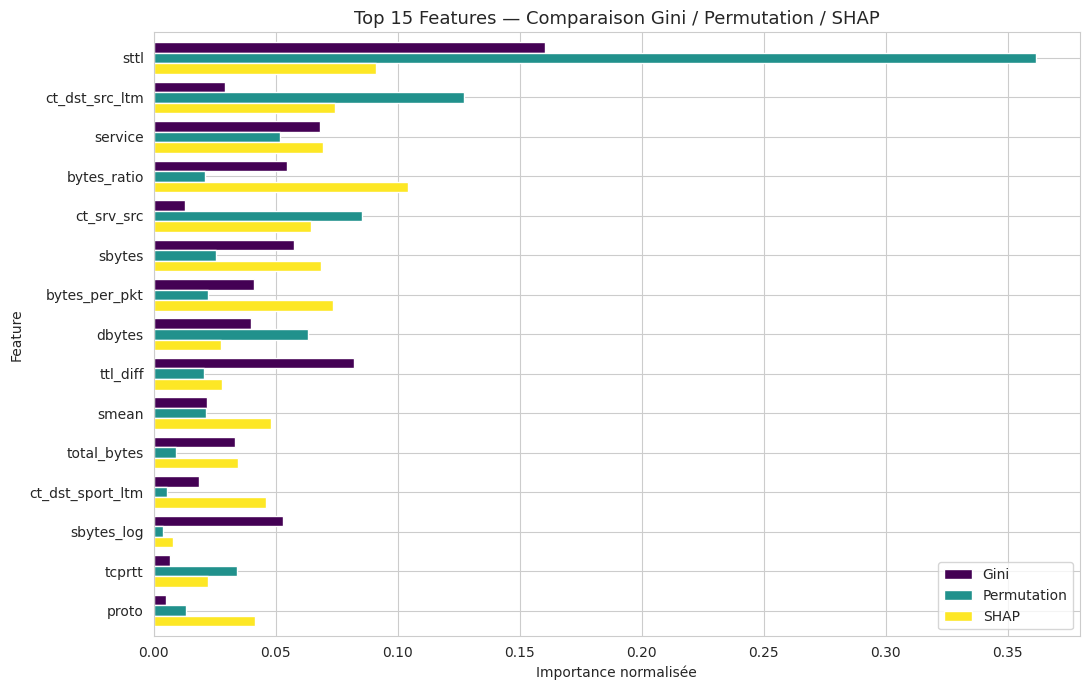

In [15]:
# Visualisation : top 15 par moyenne des 3 méthodes
top = cmp_df.head(15).set_index('Feature')[['Gini', 'Permutation', 'SHAP']]

fig, ax = plt.subplots(figsize=(11, 7))
top.plot(kind='barh', ax=ax, width=0.8, colormap='viridis')
ax.invert_yaxis()
ax.set_xlabel('Importance normalisée')
ax.set_title('Top 15 Features — Comparaison Gini / Permutation / SHAP', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


### Interprétation — Consensus entre méthodes

**Pourquoi comparer ?** Aucune méthode n'est parfaite :

| Méthode | Force | Faiblesse |
|---------|-------|-----------|
| **Gini** | Gratuit, rapide | Biais cardinalité, dilution sur features corrélées |
| **Permutation** | Model-agnostic, mesure l'impact réel | Sous-estime les features redondantes, coût élevé |
| **SHAP** | Théoriquement optimal, signe et magnitude, local+global | Coût le plus élevé |

**Features consensuelles (top des 3 méthodes)** → ce sont les **vraies features critiques** pour la détection. Ce sont celles à surveiller en priorité, à monitorer en production, et sur lesquelles un attaquant tenterait d'évader le modèle (adversarial attack).

**Features présentes seulement en Gini** → probablement à haute cardinalité (`proto`, `service`). Leur importance réelle est plus faible qu'annoncée.

**Features présentes seulement en Permutation/SHAP** → features portant une information unique que le modèle utilise intensivement mais distribuée sur peu de splits.


---
## 7. Synthèse XAI

### Ce que l'XAI nous a appris

1. **Le modèle n'est plus une boîte noire.** On peut justifier chaque alerte au niveau d'une connexion individuelle (waterfall SHAP).
2. **Les features les plus critiques sont interprétables** : débit, durée, compteurs de contexte, TTL. Ce sont les signaux qu'un expert SOC utiliserait manuellement → **le modèle a appris les bonnes heuristiques**.
3. **Le feature engineering de la Phase 3 est validé** : les features dérivées (`bytes_ratio`, `*_log`, `ttl_diff`) apparaissent dans le top consensuel → elles ont apporté de l'information utile.
4. **Chaque classe d'attaque a sa signature** (heatmap SHAP par classe) : le modèle n'est pas un classificateur binaire déguisé — il a bien appris des patterns distincts.
5. **Les erreurs sont diagnostiquables** (waterfall SHAP sur les faux positifs/négatifs) — utile pour la prochaine itération.

### Livrables Phase 5

| Artefact | Contenu |
|----------|---------|
| `data/processed/xai_feature_importance.csv` | Tableau consolidé des 3 méthodes |

### Prochaines étapes (Phase 4 → 6)

- **Phase 4** : courbes ROC/PR, analyse FP/FN avec impact métier, tests de robustesse.
- **Phase 5** : intégrer les waterfalls SHAP dans l'interface web (justification d'alerte).
- **Phase 6** : rapport final et soutenance.


In [16]:
# ============================================================
# EXPORT DES RÉSULTATS XAI
# ============================================================
cmp_df.to_csv('data/processed/xai_feature_importance.csv', index=False)
print(f"✔ Sauvegardé : data/processed/xai_feature_importance.csv  ({len(cmp_df)} features)")
print("\n=== Phase 5 (XAI) terminée ===")


✔ Sauvegardé : data/processed/xai_feature_importance.csv  (42 features)

=== Phase 5 (XAI) terminée ===
